# Linear Regression with Breast Cancer Dataset

## Step 1: Load Data

In [2]:
import pandas as pd
dataset_url = 'https://raw.githubusercontent.com/datasets/breast-cancer/refs/heads/main/data/breast-cancer.csv'

# Load the dataset
df = pd.read_csv(dataset_url)
display(df.head())

,age,mefalsepause,tumor-size,inv-falsedes,falsede-caps,deg-malig,breast,breast-quad,irradiat,class
0,40-49,premefalse,15-19,0-2,True,3,right,left_up,False,recurrence-events
1,50-59,ge40,15-19,0-2,False,1,right,central,False,false-recurrence-events
2,50-59,ge40,35-39,0-2,False,2,left,left_low,False,recurrence-events
3,40-49,premefalse,35-39,0-2,True,3,right,left_low,True,false-recurrence-events
4,40-49,premefalse,30-34,3-5,True,2,left,right_up,False,recurrence-events


## Step 2: Data Preprocessing

In [3]:
# Display information about the DataFrame, including data types and non-null values
print("DataFrame Info:")
df.info()

print("\nMissing values per column:")
# Check for missing values in each column
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   age           272 non-null    object
 1   mefalsepause  272 non-null    object
 2   tumor-size    272 non-null    object
 3   inv-falsedes  272 non-null    object
 4   falsede-caps  264 non-null    object
 5   deg-malig     272 non-null    int64 
 6   breast        272 non-null    object
 7   breast-quad   271 non-null    object
 8   irradiat      272 non-null    bool  
 9   class         272 non-null    object
dtypes: bool(1), int64(1), object(8)
memory usage: 19.5+ KB

Missing values per column:
falsede-caps    8
breast-quad     1
dtype: int64


In [4]:
# Impute missing values for 'falsede-caps' and 'breast-quad' with their mode
df['falsede-caps'] = df['falsede-caps'].fillna(df['falsede-caps'].mode()[0])
df['breast-quad'] = df['breast-quad'].fillna(df['breast-quad'].mode()[0])

print("Missing values after imputation:")
print(df.isnull().sum()[df.isnull().sum()>0])

Missing values after imputation:
Series([], dtype: int64)


C:\Users\User\AppData\Local\Temp\ipykernel_11312\2173125662.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['falsede-caps'] = df['falsede-caps'].fillna(df['falsede-caps'].mode()[0])


## Step 3: Feature Engineering and Target Definition

In [5]:
# Define target variable and features
target = 'deg-malig'
features = df.drop(columns=[target]).columns

# Identify categorical and numerical features
categorical_features = df[features].select_dtypes(include='object').columns
numerical_features = df[features].select_dtypes(include=['int64', 'float64', 'bool']).columns

print(f"Target variable: {target}")
print(f"Categorical features: {list(categorical_features)}")
print(f"Numerical features: {list(numerical_features)}")

# Perform one-hot encoding for categorical features
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# Display the head of the encoded DataFrame and its shape
display(df_encoded.head())
print(f"Shape of DataFrame after encoding: {df_encoded.shape}")

Target variable: deg-malig
Categorical features: ['age', 'mefalsepause', 'tumor-size', 'inv-falsedes', 'breast', 'breast-quad', 'class']
Numerical features: ['falsede-caps', 'irradiat']


,falsede-caps,deg-malig,irradiat,age_30-39,age_40-49,age_50-59,age_60-69,age_70-79,mefalsepause_lt40,mefalsepause_premefalse,...,inv-falsedes_24-26,inv-falsedes_3-5,inv-falsedes_6-8,inv-falsedes_9-11,breast_right,breast-quad_left_low,breast-quad_left_up,breast-quad_right_low,breast-quad_right_up,class_recurrence-events
0,True,3,False,False,True,False,False,False,False,True,...,False,False,False,False,True,False,True,False,False,True
1,False,1,False,False,False,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,False,2,False,False,False,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
3,True,3,True,False,True,False,False,False,False,True,...,False,False,False,False,True,True,False,False,False,False
4,True,2,False,False,True,False,False,False,False,True,...,False,True,False,False,False,False,False,False,True,True


Shape of DataFrame after encoding: (272, 32)


## Step 4: Model Training

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Define features (X) and target (y)
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape: {X_test_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("\nLinear Regression model trained successfully!")

X_train shape: (217, 31)
X_test shape: (55, 31)
y_train shape: (217,)
y_test shape: (55,)

Linear Regression model trained successfully!


## Step 5: Model Evaluation

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.6500
Mean Squared Error (MSE): 0.6164
Root Mean Squared Error (RMSE): 0.7851
R-squared (R2) Score: -0.2029


## Step 6: Sample Predictions and Visualizations

,Actual,Predicted
0,3,1.821720
1,2,2.084645
2,2,2.006446
3,3,1.901782
4,1,1.655363
5,2,2.255898
6,1,2.544248
7,2,2.219643
8,3,1.588260
9,2,2.363257


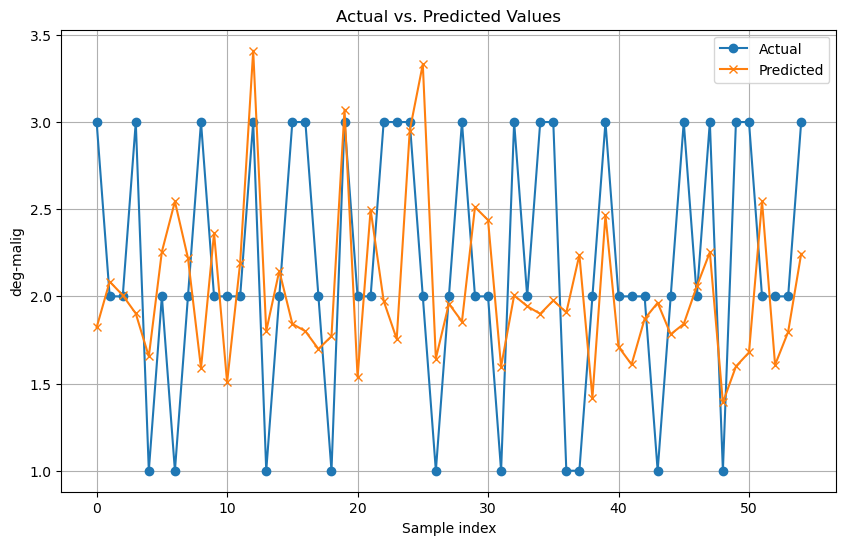

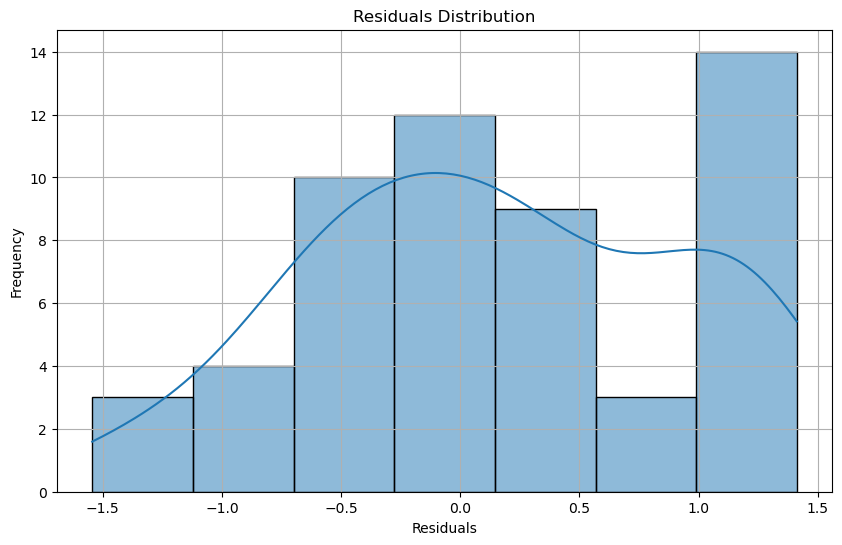

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display sample predictions
predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}).reset_index(drop=True)
display(predictions_df.head(10))

# Plot actual and predicted values as two lines
plt.figure(figsize=(10, 6))
plt.plot(predictions_df.index, predictions_df['Actual'], label='Actual', marker='o')
plt.plot(predictions_df.index, predictions_df['Predicted'], label='Predicted', marker='x')
plt.title('Actual vs. Predicted Values')
plt.xlabel('Sample index')
plt.ylabel('deg-malig')
plt.legend()
plt.grid(True)
plt.show()

# Plotting residuals
residuals = y_test.reset_index(drop=True) - predictions_df['Predicted']
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

Text(0, 0.5, 'Error')

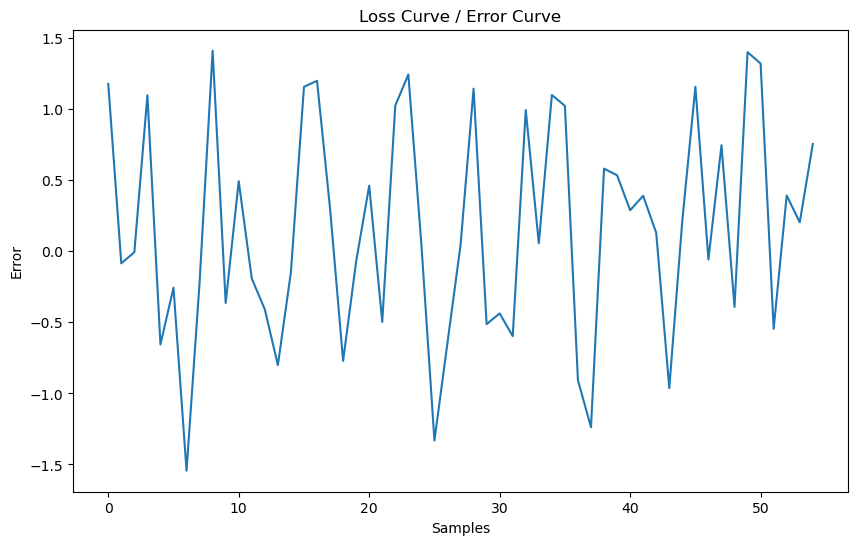

In [9]:
#Loss Curve / Error Curve
errors=y_test-y_pred
plt.figure(figsize=(10, 6))
sns.lineplot(x=range(len(errors)), y=errors)
plt.title('Loss Curve / Error Curve')
plt.xlabel('Samples')
plt.ylabel('Error')